In [23]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = datasource.get_codes()
code = codes[0]
dt = datasource.get_data(code)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
date,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0


In [18]:
# 我这里需要查看涨停前N天最大值最小值的情况
BEFORE = 10 # 前面10个交易日的情况
dt[f'high{BEFORE}'] = dt['high'].rolling(window=BEFORE).max().shift(1) # 几天的最高值
dt[f'low{BEFORE}'] = dt['low'].rolling(window=BEFORE).min().shift(1)   # 几天的最低值
dt[f'zhenfu{BEFORE}'] = (dt[f'high{BEFORE}']-dt[f'low{BEFORE}'])/dt[f'low{BEFORE}']*100
dt['isMust'] = (dt['close']-dt['preclose'])/dt['preclose']>0.095 # 是否涨停，这里是9.5%
dt2 = dt.loc[dt['isMust']==True,['code',  f'high{BEFORE}', f'low{BEFORE}', f'zhenfu{BEFORE}']]
dt2.head()

,code,high10,low10,zhenfu10
date,,,,
2013-09-09,sh.600000,4.333897,3.688423,17.500000
2014-03-21,sh.600000,4.052875,3.684032,10.011919
2017-05-25,sh.600000,8.695970,8.126291,7.010309


In [19]:
dt2[f'zhenfu{BEFORE}']=dt2[f'zhenfu{BEFORE}'].astype(int)
dt2.head()

,code,high10,low10,zhenfu10
date,,,,
2013-09-09,sh.600000,4.333897,3.688423,17
2014-03-21,sh.600000,4.052875,3.684032,10
2017-05-25,sh.600000,8.695970,8.126291,7


<BarContainer object of 3 artists>

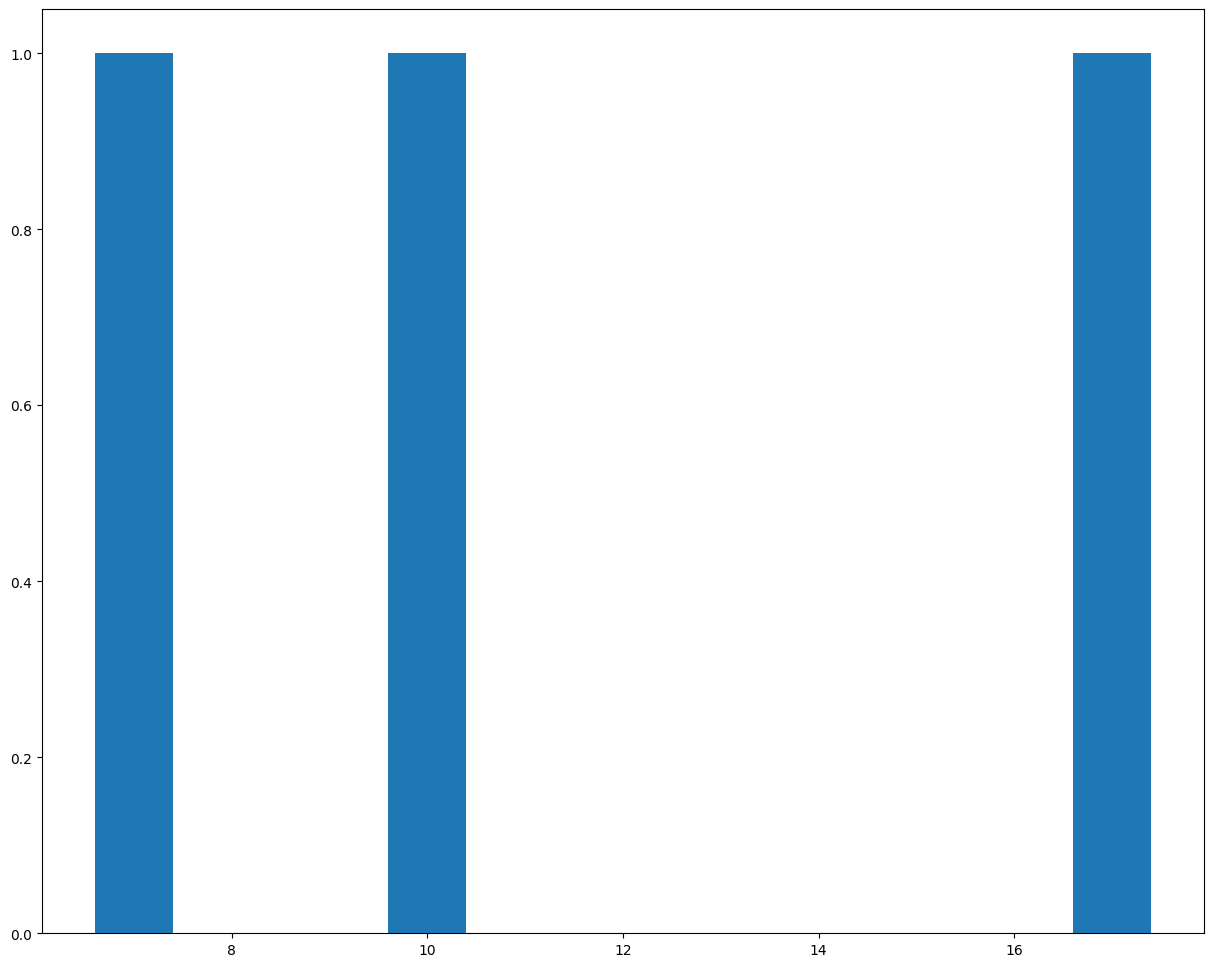

In [22]:
dt3 = dt2.groupby('zhenfu10').size().reset_index().rename(columns={0:'count'})
dt3.head()
plt.figure(figsize=(15, 12))
plt.bar(dt3['zhenfu10'], dt3['count'])


In [44]:
# 我这里希望看到涨停前多少天的
BEFORE_MAX = 30  # 涨停前往前看多少天
lst_dts = [[] for i in range(BEFORE_MAX)] # 涨停前的统计保存在这里边


for i in tqdm(range(len(codes))):
    code = codes[i]
    dt = datasource.get_data(code)
    # 然后这里取得多少天的
    for before in range(BEFORE_MAX):
        # 先计算
        dt[f'high{before}'] = dt['high'].rolling(window=before).max().shift(1) # 几天的最高值
        dt[f'low{before}'] = dt['low'].rolling(window=before).min().shift(1)   # 几天的最低值
        dt[f'zhenfu{before}'] = (dt[f'high{before}']-dt[f'low{before}'])/dt[f'low{before}']*100 # 振幅，以最低点为准
        dt['isMust'] = (dt['close']-dt['preclose'])/dt['preclose']>0.095 # 是否涨停，这里是9.5%
        # 再筛选
        dt2 = dt.loc[dt['isMust']==True,['code',  f'high{before}', f'low{before}', f'zhenfu{before}']].dropna()
        dt2[f'zhenfu{before}']=dt2[f'zhenfu{before}'].astype(int)
        # 再统计
        dt3 = dt2.groupby(f'zhenfu{before}').size().reset_index().rename(columns={0:'count'})
        # 保存起来
        if len(dt3) > 0:
            lst_dts[before].append(dt3)
        

100%|██████████████████████████████████████████████████████████████████████████████| 5493/5493 [19:01<00:00,  4.81it/s]


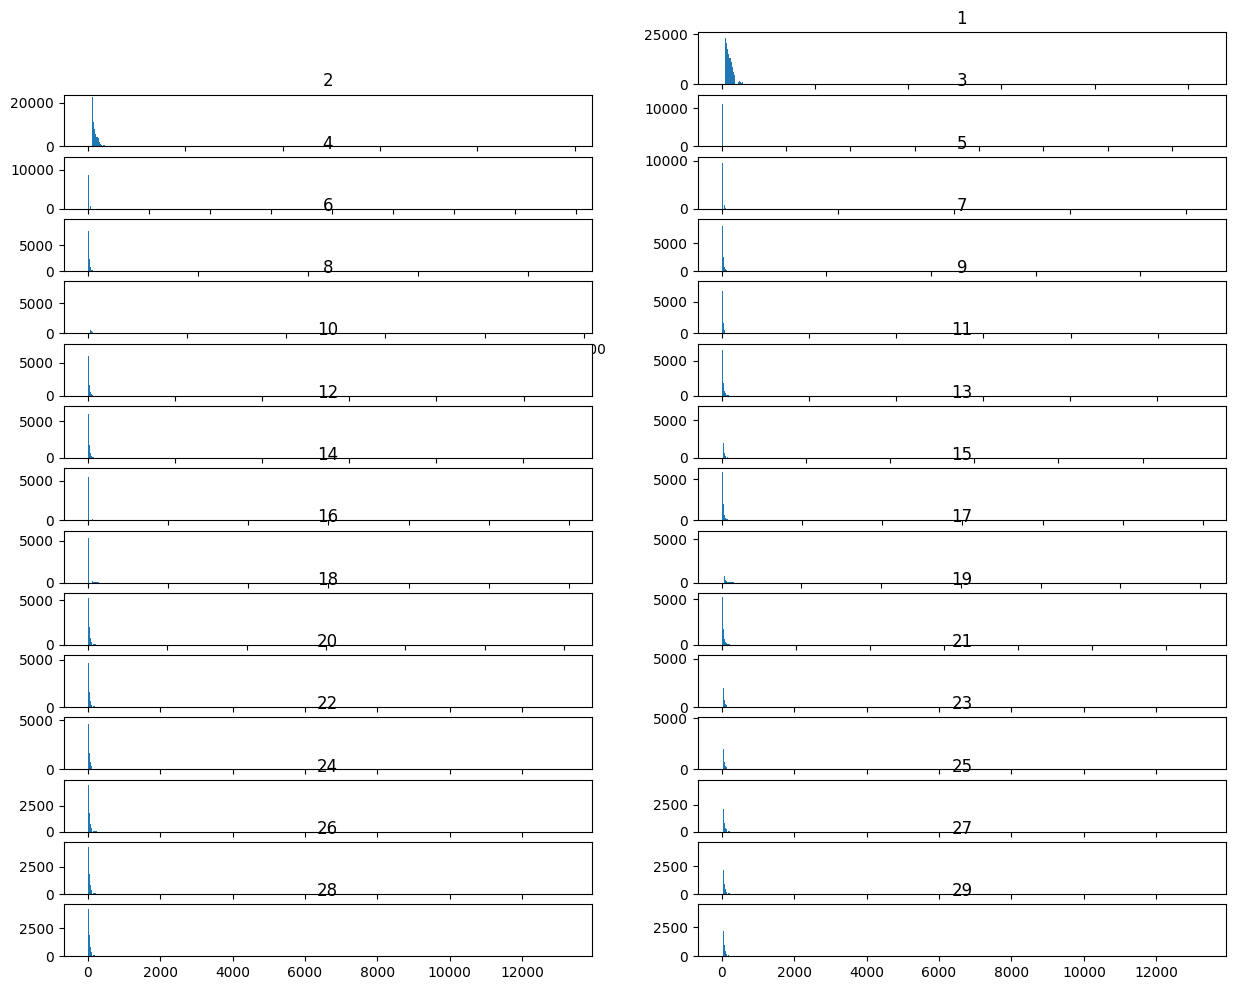

In [54]:
# 这里画图，

plt.figure(figsize=(15, 12)) # 图片的尺寸
COLUMN = 2                   # 
ROW_MAX = math.ceil(BEFORE_MAX/COLUMN)
lst_dt_zhenfu = {}
for before in range(BEFORE_MAX):
    # 首先拼接
    if len(lst_dts[before]) >0:
        dt_all = pd.concat(lst_dts[before],  ignore_index=True).dropna().groupby(f'zhenfu{before}').agg({'count':['sum']}).reset_index().rename(columns={0:'sum'})
        plt.subplot(ROW_MAX, COLUMN, before+1)
        plt.bar(dt_all[f'zhenfu{before}'], dt_all['count','sum'])
        plt.title(f'{before}')
        lst_dt_zhenfu[before]=dt_all.loc[:,:]
    pass

In [56]:
lst_dt_zhenfu[10]

,zhenfu10,count
,,sum
0,0,9
1,2,47
2,3,278
3,4,826
4,5,1658
...,...,...
286,1095,1
287,1148,1
288,1214,1


In [71]:
# 我想看看最高点是哪个
for before in lst_dt_zhenfu:
    dt = lst_dt_zhenfu[before]
    # 然后我这里需要知道哪个最高
    _max_sum = dt.max()['count','sum'].item()
    dt2 = dt.loc[dt['count','sum']== _max_sum, :]
    zhenfu = dt2.iat[0, 0]
    print(f'{before}:{zhenfu}')

1:0
2:10
3:21
4:33
5:11
6:12
7:12
8:12
9:13
10:13
11:14
12:15
13:16
14:16
15:17
16:17
17:17
18:20
19:19
20:20
21:21
22:21
23:21
24:21
25:23
26:21
27:23
28:23
29:26


In [69]:
# 看起来像是在15%以内的振幅，机会最多

7476